In [1]:
# ============================================================
# F1M1 — Módulo 1: EDA Leonali
# Notebook 03 — EDA Bivariado
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_parquet('../data/processed/Dataset1_anonimizado.parquet')

# Variable derivada útil para análisis bivariado
df['precio_unitario'] = df['Costo_Venta'] / df['Piezas_Entregadas'].replace(0, np.nan)
df['año'] = df['FechaProceso'].dt.year
df['mes'] = df['FechaProceso'].dt.month

print(f"✓ Dataset cargado: {df.shape}")
print(f"  Variables nuevas: precio_unitario, año, mes")

✓ Dataset cargado: (581306, 18)
  Variables nuevas: precio_unitario, año, mes


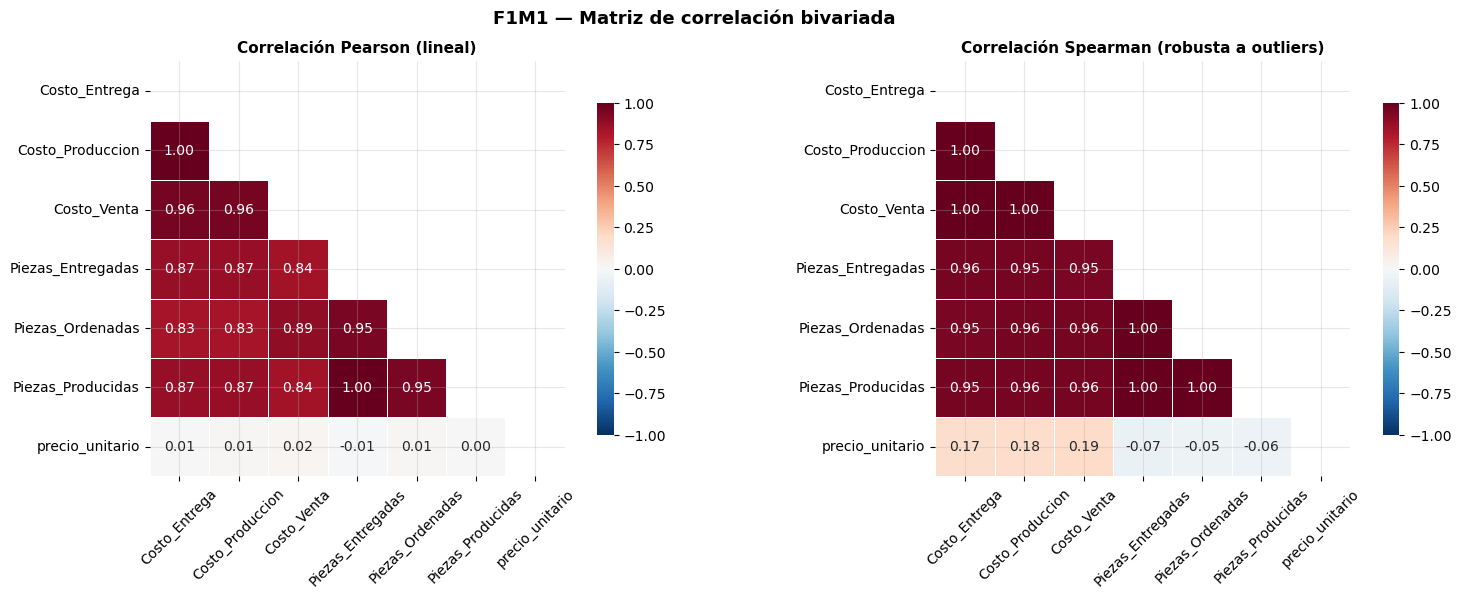

In [2]:
# ============================================================
# BLOQUE 1 — MATRIZ DE CORRELACIÓN
# ============================================================

numericas = ['Costo_Entrega', 'Costo_Produccion', 'Costo_Venta',
             'Piezas_Entregadas', 'Piezas_Ordenadas', 'Piezas_Producidas',
             'precio_unitario']

# Muestra para Spearman (más robusta con outliers)
muestra = df[numericas].dropna().sample(20000, random_state=42)

corr_pearson   = muestra.corr(method='pearson')
corr_spearman  = muestra.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, corr, titulo in zip(axes,
    [corr_pearson, corr_spearman],
    ['Pearson (lineal)', 'Spearman (robusta a outliers)']):
    
    mask = np.triu(np.ones_like(corr, dtype=bool))  # solo triángulo inferior
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, center=0, ax=ax,
                mask=mask, square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_title(f'Correlación {titulo}', fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('F1M1 — Matriz de correlación bivariada', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_correlacion_matriz.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\Said\AppData\Local\Temp\ipykernel_15124\4196622130.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_canales, labels=canales_orden, patch_artist=True,


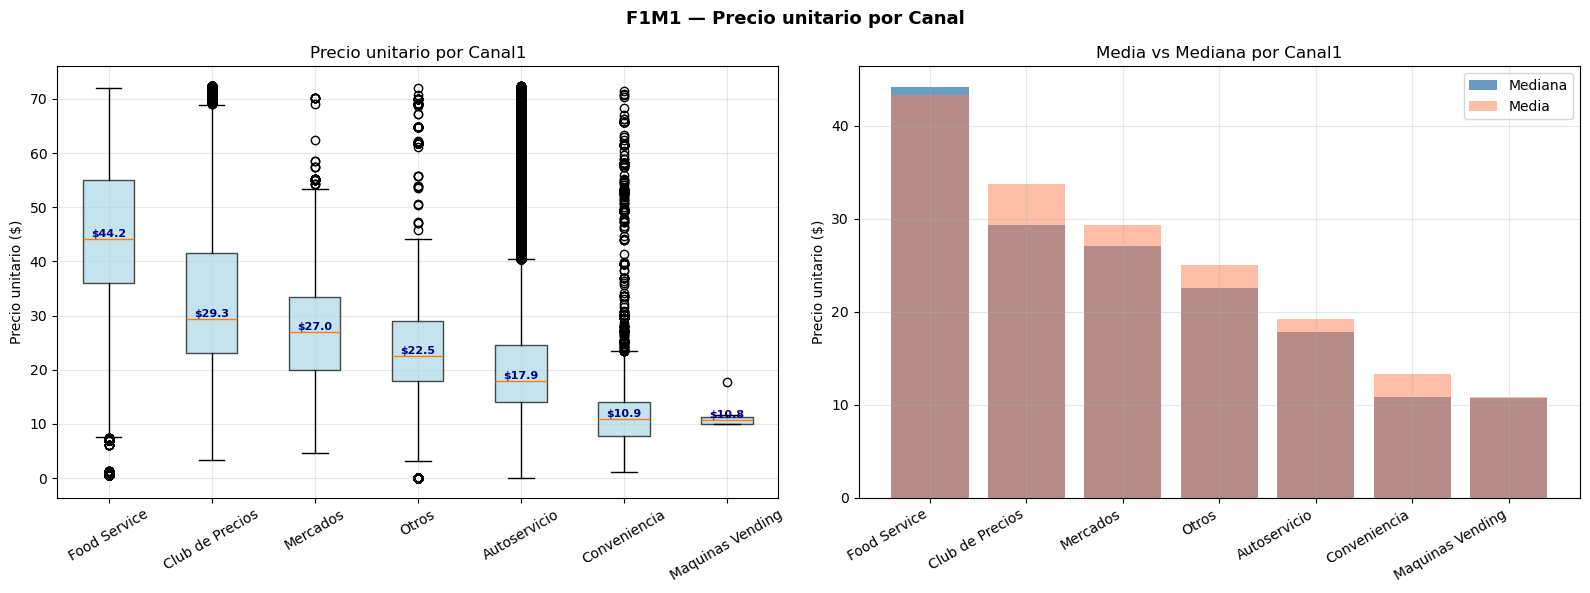

=== PRECIO UNITARIO POR CANAL ===
                  median   mean    std   count
Canal1                                        
Food Service       44.16  43.33  15.41   12682
Club de Precios    29.30  33.72  14.47   27161
Mercados           27.00  29.33  12.63     598
Otros              22.50  24.99  18.38    2160
Autoservicio       17.86  19.18   7.73  428240
Conveniencia       10.86  13.29   9.93   12567
Maquinas Vending   10.75  10.78   0.85     181


In [3]:
# ============================================================
# BLOQUE 2 — CANAL vs PRECIO UNITARIO
# ============================================================

# Filtrar outliers extremos para visualización limpia
df_viz = df[
    (df['precio_unitario'] > df['precio_unitario'].quantile(0.01)) &
    (df['precio_unitario'] < df['precio_unitario'].quantile(0.99))
].dropna(subset=['precio_unitario'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Boxplot precio_unitario por Canal1 ---
canales_orden = df_viz.groupby('Canal1')['precio_unitario']\
                      .median().sort_values(ascending=False).index

ax = axes[0]
data_canales = [df_viz[df_viz['Canal1']==c]['precio_unitario'].values 
                for c in canales_orden]
bp = ax.boxplot(data_canales, labels=canales_orden, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7))
ax.set_title('Precio unitario por Canal1')
ax.set_ylabel('Precio unitario ($)')
ax.tick_params(axis='x', rotation=30)

# Agregar mediana como texto
for i, c in enumerate(canales_orden):
    med = df_viz[df_viz['Canal1']==c]['precio_unitario'].median()
    ax.text(i+1, med, f'${med:.1f}', ha='center', va='bottom', 
            fontsize=8, fontweight='bold', color='navy')

# --- Plot 2: Estadísticos por canal ---
ax = axes[1]
stats_canal = df_viz.groupby('Canal1')['precio_unitario'].agg([
    'median', 'mean', 'std', 'count'
]).round(2).sort_values('median', ascending=False)

x = range(len(stats_canal))
ax.bar(x, stats_canal['median'], color='steelblue', alpha=0.8, label='Mediana')
ax.bar(x, stats_canal['mean'], color='coral', alpha=0.5, label='Media')
ax.set_xticks(x)
ax.set_xticklabels(stats_canal.index, rotation=30, ha='right')
ax.set_title('Media vs Mediana por Canal1')
ax.set_ylabel('Precio unitario ($)')
ax.legend()

plt.suptitle('F1M1 — Precio unitario por Canal', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_canal_vs_precio.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla resumen
print("=== PRECIO UNITARIO POR CANAL ===")
print(stats_canal.to_string())

C:\Users\Said\AppData\Local\Temp\ipykernel_15124\3268692405.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_cat, labels=cat_orden, patch_artist=True,


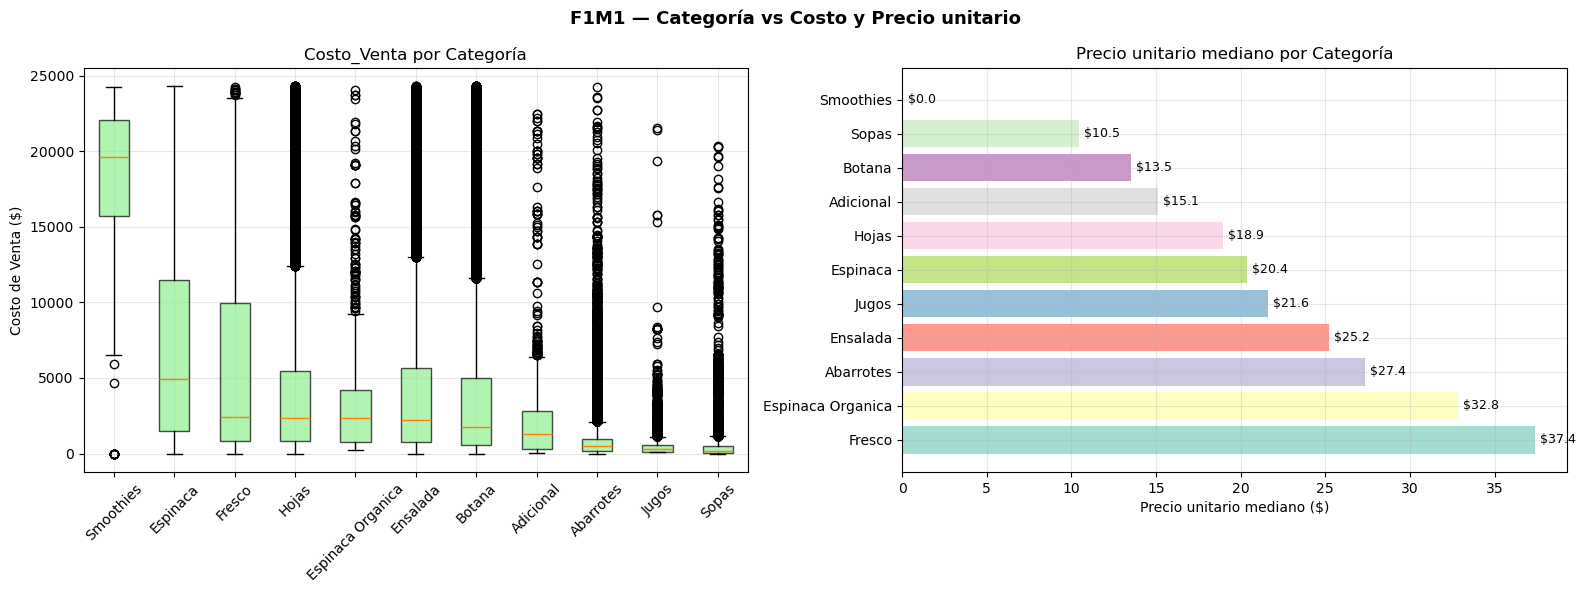

=== PRECIO UNITARIO POR CATEGORÍA ===
                   median   mean   count
Categoria1                              
Fresco              37.38  40.54    2437
Espinaca Organica   32.83  34.77    1019
Abarrotes           27.35  27.79   61439
Ensalada            25.23  25.45   75911
Jugos               21.63  21.97    7582
Espinaca            20.38  22.97   54074
Hojas               18.93  22.38   88695
Adicional           15.09  15.40    3572
Botana              13.50  14.47  175190
Sopas               10.46  11.92   13646
Smoothies            0.02  28.86      24


In [4]:
# ============================================================
# BLOQUE 3 — CATEGORÍA vs COSTO DE VENTA
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Boxplot Costo_Venta por Categoria1 ---
# Filtrar para visualización
df_cat = df[
    (df['Costo_Venta'] > 0) &
    (df['Costo_Venta'] < df['Costo_Venta'].quantile(0.95))
]

cat_orden = df_cat.groupby('Categoria1')['Costo_Venta']\
                  .median().sort_values(ascending=False).index

ax = axes[0]
data_cat = [df_cat[df_cat['Categoria1']==c]['Costo_Venta'].values 
            for c in cat_orden]
ax.boxplot(data_cat, labels=cat_orden, patch_artist=True,
           boxprops=dict(facecolor='lightgreen', alpha=0.7))
ax.set_title('Costo_Venta por Categoría')
ax.set_ylabel('Costo de Venta ($)')
ax.tick_params(axis='x', rotation=45)

# --- Plot 2: Precio unitario por Categoria1 ---
ax = axes[1]
stats_cat = df_viz.groupby('Categoria1')['precio_unitario'].agg([
    'median', 'mean', 'count'
]).round(2).sort_values('median', ascending=False)

colors = plt.cm.Set3(np.linspace(0, 1, len(stats_cat)))
bars = ax.barh(stats_cat.index, stats_cat['median'], color=colors, alpha=0.8)
ax.set_title('Precio unitario mediano por Categoría')
ax.set_xlabel('Precio unitario mediano ($)')

for bar, val in zip(bars, stats_cat['median']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'${val:.1f}', va='center', fontsize=9)

plt.suptitle('F1M1 — Categoría vs Costo y Precio unitario',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_categoria_vs_costo.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== PRECIO UNITARIO POR CATEGORÍA ===")
print(stats_cat.to_string())

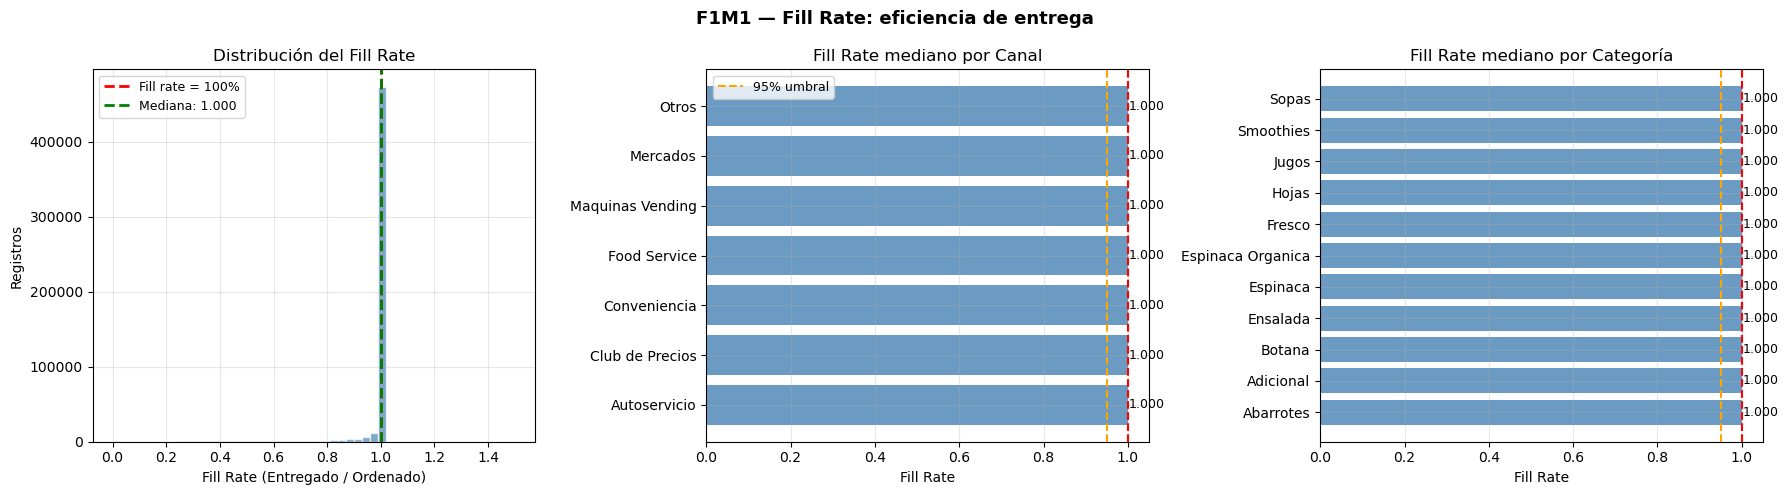

=== FILL RATE POR CANAL ===
                  median   mean    std
Canal1                                
Autoservicio         1.0  0.980  0.095
Club de Precios      1.0  0.982  0.089
Conveniencia         1.0  0.977  0.092
Food Service         1.0  0.979  0.099
Maquinas Vending     1.0  0.998  0.032
Mercados             1.0  0.977  0.112
Otros                1.0  0.999  0.023

=== FILL RATE GLOBAL ===
Mediana global: 1.0000
% registros con fill rate = 1.0: 89.3%
% registros con fill rate < 0.95: 6.1%


In [5]:
# ============================================================
# BLOQUE 4 — FILL RATE: PIEZAS ORDENADAS vs ENTREGADAS
# ============================================================

# Fill rate = Piezas_Entregadas / Piezas_Ordenadas
df['fill_rate'] = df['Piezas_Entregadas'] / df['Piezas_Ordenadas'].replace(0, np.nan)

# Filtrar registros válidos
df_fr = df[
    (df['Piezas_Ordenadas'] > 0) &
    (df['fill_rate'] > 0) &
    (df['fill_rate'] <= 1.5)  # excluir sobre-entregas extremas
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Distribución del fill rate ---
ax = axes[0]
ax.hist(df_fr['fill_rate'], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Fill rate = 100%')
ax.axvline(df_fr['fill_rate'].median(), color='green', linestyle='--',
           linewidth=2, label=f"Mediana: {df_fr['fill_rate'].median():.3f}")
ax.set_title('Distribución del Fill Rate')
ax.set_xlabel('Fill Rate (Entregado / Ordenado)')
ax.set_ylabel('Registros')
ax.legend(fontsize=9)

# --- Plot 2: Fill rate por Canal1 ---
ax = axes[1]
fr_canal = df_fr.groupby('Canal1')['fill_rate'].median().sort_values(ascending=True)
colors = ['red' if v < 0.95 else 'steelblue' for v in fr_canal.values]
ax.barh(fr_canal.index, fr_canal.values, color=colors, alpha=0.8)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(0.95, color='orange', linestyle='--', linewidth=1.5, label='95% umbral')
ax.set_title('Fill Rate mediano por Canal')
ax.set_xlabel('Fill Rate')
ax.legend(fontsize=9)
for i, v in enumerate(fr_canal.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

# --- Plot 3: Fill rate por Categoria1 ---
ax = axes[2]
fr_cat = df_fr.groupby('Categoria1')['fill_rate'].median().sort_values(ascending=True)
colors_cat = ['red' if v < 0.95 else 'steelblue' for v in fr_cat.values]
ax.barh(fr_cat.index, fr_cat.values, color=colors_cat, alpha=0.8)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(0.95, color='orange', linestyle='--', linewidth=1.5)
ax.set_title('Fill Rate mediano por Categoría')
ax.set_xlabel('Fill Rate')
for i, v in enumerate(fr_cat.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('F1M1 — Fill Rate: eficiencia de entrega',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_fill_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== FILL RATE POR CANAL ===")
print(df_fr.groupby('Canal1')['fill_rate'].agg(['median','mean','std']).round(3))
print("\n=== FILL RATE GLOBAL ===")
print(f"Mediana global: {df_fr['fill_rate'].median():.4f}")
print(f"% registros con fill rate = 1.0: {(df_fr['fill_rate']==1.0).sum()/len(df_fr)*100:.1f}%")
print(f"% registros con fill rate < 0.95: {(df_fr['fill_rate']<0.95).sum()/len(df_fr)*100:.1f}%")

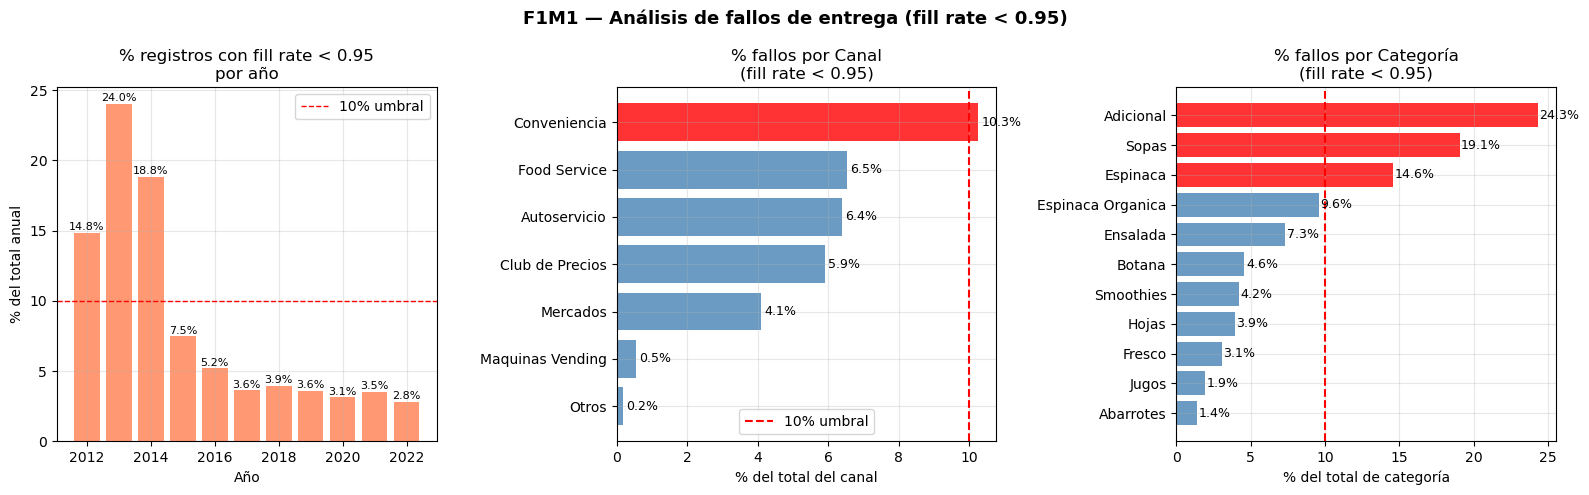

Total registros con fallo: 31,628 (6.1%)

% fallos por año:
año
2012    14.8
2013    24.0
2014    18.8
2015     7.5
2016     5.2
2017     3.6
2018     3.9
2019     3.6
2020     3.1
2021     3.5
2022     2.8


In [6]:
# ============================================================
# ZOOM — Registros con Fill Rate < 0.95
# ============================================================

df_fallo = df_fr[df_fr['fill_rate'] < 0.95].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Fill rate < 0.95 por año ---
ax = axes[0]
fallos_año = df_fallo.groupby('año').size()
total_año  = df_fr.groupby('año').size()
pct_fallo  = (fallos_año / total_año * 100).fillna(0)

ax.bar(pct_fallo.index, pct_fallo.values, color='coral', alpha=0.8)
ax.set_title('% registros con fill rate < 0.95\npor año')
ax.set_xlabel('Año')
ax.set_ylabel('% del total anual')
ax.axhline(10, color='red', linestyle='--', linewidth=1, label='10% umbral')
ax.legend()
for i, (yr, v) in enumerate(pct_fallo.items()):
    ax.text(yr, v + 0.2, f'{v:.1f}%', ha='center', fontsize=8)

# --- Plot 2: Fill rate < 0.95 por Canal ---
ax = axes[1]
fallos_canal = df_fallo.groupby('Canal1').size()
total_canal  = df_fr.groupby('Canal1').size()
pct_canal    = (fallos_canal / total_canal * 100).sort_values(ascending=True)

colors = ['red' if v > 10 else 'steelblue' for v in pct_canal.values]
ax.barh(pct_canal.index, pct_canal.values, color=colors, alpha=0.8)
ax.axvline(10, color='red', linestyle='--', linewidth=1.5, label='10% umbral')
ax.set_title('% fallos por Canal\n(fill rate < 0.95)')
ax.set_xlabel('% del total del canal')
ax.legend()
for i, v in enumerate(pct_canal.values):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

# --- Plot 3: Fill rate < 0.95 por Categoria ---
ax = axes[2]
fallos_cat = df_fallo.groupby('Categoria1').size()
total_cat  = df_fr.groupby('Categoria1').size()
pct_cat    = (fallos_cat / total_cat * 100).sort_values(ascending=True)

colors_cat = ['red' if v > 10 else 'steelblue' for v in pct_cat.values]
ax.barh(pct_cat.index, pct_cat.values, color=colors_cat, alpha=0.8)
ax.axvline(10, color='red', linestyle='--', linewidth=1.5)
ax.set_title('% fallos por Categoría\n(fill rate < 0.95)')
ax.set_xlabel('% del total de categoría')
for i, v in enumerate(pct_cat.values):
    ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('F1M1 — Análisis de fallos de entrega (fill rate < 0.95)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_fill_rate_fallos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total registros con fallo: {len(df_fallo):,} ({len(df_fallo)/len(df_fr)*100:.1f}%)")
print(f"\n% fallos por año:")
print(pct_fallo.round(1).to_string())

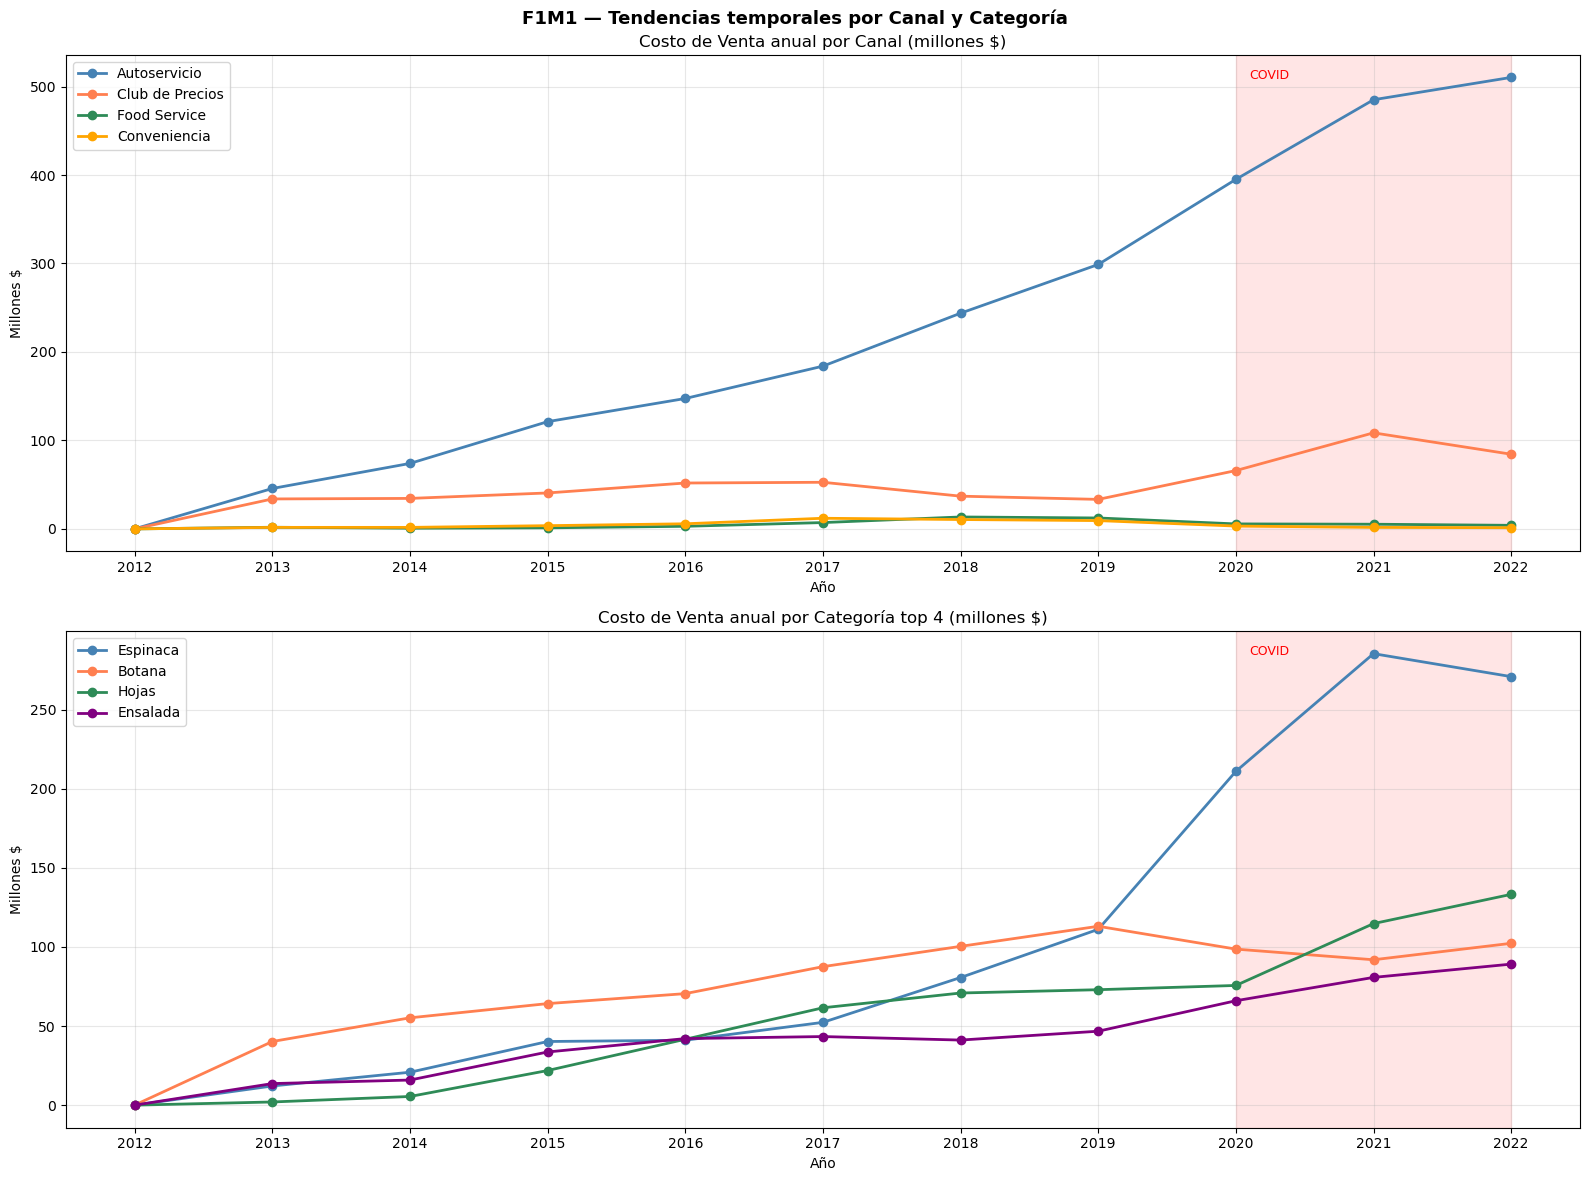

In [7]:
# ============================================================
# BLOQUE 5 — TENDENCIA TEMPORAL POR CANAL Y CATEGORÍA
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# --- Plot 1: Ventas anuales por Canal1 ---
ax = axes[0]
ventas_canal_año = df.groupby(['año', 'Canal1'])['Costo_Venta'].sum() / 1e6
ventas_canal_año = ventas_canal_año.reset_index()

canales_top = ['Autoservicio', 'Club de Precios', 'Food Service', 'Conveniencia']
colores = ['steelblue', 'coral', 'seagreen', 'orange']

for canal, color in zip(canales_top, colores):
    data = ventas_canal_año[ventas_canal_año['Canal1'] == canal]
    ax.plot(data['año'], data['Costo_Venta'], 
            marker='o', linewidth=2, color=color, label=canal)

ax.set_title('Costo de Venta anual por Canal (millones $)')
ax.set_xlabel('Año')
ax.set_ylabel('Millones $')
ax.legend()
ax.set_xticks(df['año'].unique())

# --- Plot 2: Ventas anuales por Categoria1 top 4 ---
ax = axes[1]
ventas_cat_año = df.groupby(['año', 'Categoria1'])['Costo_Venta'].sum() / 1e6
ventas_cat_año = ventas_cat_año.reset_index()

cats_top = ['Espinaca', 'Botana', 'Hojas', 'Ensalada']
colores2 = ['steelblue', 'coral', 'seagreen', 'purple']

for cat, color in zip(cats_top, colores2):
    data = ventas_cat_año[ventas_cat_año['Categoria1'] == cat]
    ax.plot(data['año'], data['Costo_Venta'],
            marker='o', linewidth=2, color=color, label=cat)

ax.set_title('Costo de Venta anual por Categoría top 4 (millones $)')
ax.set_xlabel('Año')
ax.set_ylabel('Millones $')
ax.legend()
ax.set_xticks(df['año'].unique())

# Marcar COVID
for ax in axes:
    ax.axvspan(2020, 2022, alpha=0.1, color='red', label='_COVID')
    ax.text(2020.1, ax.get_ylim()[1]*0.95, 'COVID', fontsize=9, color='red')

plt.suptitle('F1M1 — Tendencias temporales por Canal y Categoría',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_tendencias_temporales.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# RESUMEN — HALLAZGOS EDA BIVARIADO
# ============================================================

print("=" * 60)
print("HALLAZGOS EDA BIVARIADO — LEONALI")
print("=" * 60)

print("""
CORRELACIONES:
  • Costo_Venta ↔ Costo_Produccion = 1.00 → redundantes en ML
  • precio_unitario ↔ todo = ~0 en Pearson → sin correlación lineal
  • Spearman detecta relación débil (0.17) precio vs costos
  • Para ver relaciones interesantes → segmentar por canal/categoría

CANAL vs PRECIO UNITARIO:
  • Food Service: $44.2 mediana — precio más alto (vendor packs,
    menor poder de negociación, sin contratos marco)
  • Club de Precios: $29.3 — presentaciones mayoreo
  • Autoservicio: $17.9 — contratos marco fijan precio, std baja
  • Conveniencia y Vending: $10-11 — presentaciones pequeñas
  • Máquinas Vending: std=$0.85 — precio programado, casi fijo

CATEGORÍA vs PRECIO:
  • Fresco: $37.4 — precio más alto (cadena de frío, merma alta)
  • Espinaca Orgánica: $32.8 — premium por sello orgánico
  • Botana: $13.5 — alto volumen, bajo precio unitario (escala)
  • Smoothies: solo 24 registros, probablemente categoría en prueba

FILL RATE:
  • 89.3% de registros = fill rate exactamente 1.0
  • 6.1% con fill rate < 0.95 — cuando falla, falla significativo
  • Mejora estructural de 2013 (24% fallos) a 2016+ (~4% fallos)
  • Conveniencia: único canal sobre 10% de fallos (10.3%)
  • Espinaca: 14.6% fallos — mayor impacto económico por volumen
  • COVID NO empeoró el fill rate — la mejora se sostuvo

TENDENCIAS TEMPORALES:
  • COVID 2020-2022: boom de Espinaca (+2.5x), Hojas, Ensalada
  • Food Service plano en COVID — restaurantes cerrados
  • Botana se estanca en COVID — menos reuniones sociales
  • Crecimiento 8x = crecimiento orgánico + salto atípico COVID
  • Período 2020-2022 debe marcarse como atípico en forecasting
""")

print("PRÓXIMOS PASOS (S5.4):")
print("  • Análisis temporal detallado — estacionalidad mensual")
print("  • Top clientes por valor y comportamiento")

HALLAZGOS EDA BIVARIADO — LEONALI

CORRELACIONES:
  • Costo_Venta ↔ Costo_Produccion = 1.00 → redundantes en ML
  • precio_unitario ↔ todo = ~0 en Pearson → sin correlación lineal
  • Spearman detecta relación débil (0.17) precio vs costos
  • Para ver relaciones interesantes → segmentar por canal/categoría

CANAL vs PRECIO UNITARIO:
  • Food Service: $44.2 mediana — precio más alto (vendor packs,
    menor poder de negociación, sin contratos marco)
  • Club de Precios: $29.3 — presentaciones mayoreo
  • Autoservicio: $17.9 — contratos marco fijan precio, std baja
  • Conveniencia y Vending: $10-11 — presentaciones pequeñas
  • Máquinas Vending: std=$0.85 — precio programado, casi fijo

CATEGORÍA vs PRECIO:
  • Fresco: $37.4 — precio más alto (cadena de frío, merma alta)
  • Espinaca Orgánica: $32.8 — premium por sello orgánico
  • Botana: $13.5 — alto volumen, bajo precio unitario (escala)
  • Smoothies: solo 24 registros, probablemente categoría en prueba

FILL RATE:
  • 89.3% de reg